In [1]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numba import njit
from scipy.stats import gaussian_kde
from scipy.linalg import eigvals
from scipy.linalg import expm

## RED DAÑADA

In [2]:
# --- CARGAR datos ---
Omega_damage_array = np.load('Omega_damage_list.npy')
Omega_damage_list = [Omega_damage_array[i] for i in range(Omega_damage_array.shape[0])]

print(Omega_damage_list)

[array([[0.00000000e+00, 1.79856115e-03, 5.55555556e-03, 2.12314225e-03,
        6.89655172e-03, 3.03030303e-02, 9.70873786e-03, 2.92397661e-03,
        2.38095238e-02, 2.84900285e-03, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.31752306e-03, 0.00000000e+00,
        0.00000000e+00, 6.49350649e-03, 0.00000000e+00, 0.00000000e+00],
       [7.93650794e-03, 0.00000000e+00, 3.92156863e-03, 5.37634409e-03,
        9.36329588e-04, 6.99300699e-03, 2.84090909e-03, 4.34782609e-03,
        1.29366106e-03, 3.79794911e-04, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.72117040e-03, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [7.16332378e-04, 5.55555556e-02, 0.00000000e+00, 3.57142857e-03,
        1.18063754e-03, 3.74531835e-03, 6.76589986e-04, 0.00000000e+00,
        2.89855072e-03, 1.50829563e-03, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.000

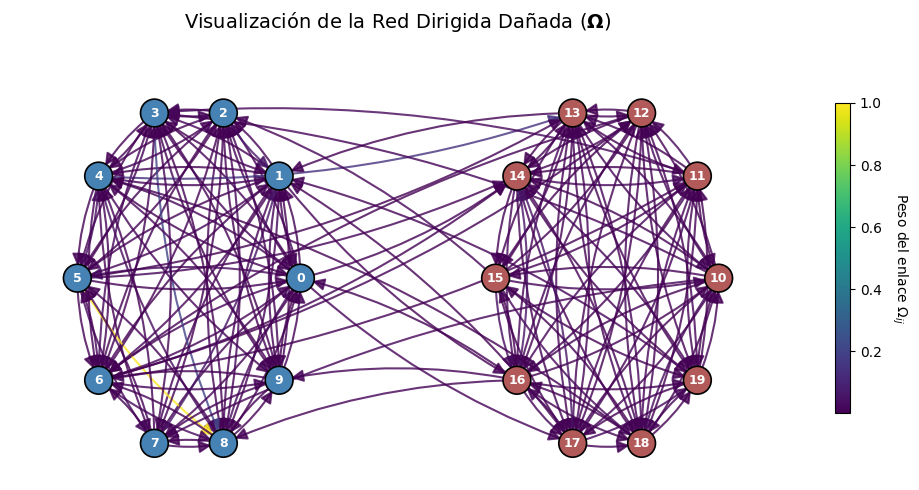

In [25]:


# Seleccionamos una matriz de peso dañada (por ejemplo, la primera simulación)
# Omega_damage_list[0]
weights_matrix = Omega_damage_list[0]

# 2. Definir posiciones (Mantenemos tu estructura de dos comunidades)
N_com = 10 
pos = {}
for i in range(N_com):
    angle = 2 * np.pi * i / N_com
    pos[i] = np.array([-1.5 + 0.8 * np.cos(angle), 0.8 * np.sin(angle)])
for i in range(N_com, 2 * N_com):
    angle = 2 * np.pi * i / N_com
    pos[i] = np.array([1.5 + 0.8 * np.cos(angle), 0.8 * np.sin(angle)])

# 3. Configuración de la gráfica
fig, ax = plt.subplots(figsize=(10, 5))
node_colors = ['steelblue'] * N_com + ['#B25A5A'] * N_com

# Extraer aristas y sus pesos correspondientes de la matriz Omega
edges = list(G.edges())
weights = [weights_matrix[u, v] for u, v in edges]

# 4. Dibujar Nodos
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=400, node_color=node_colors, 
                       edgecolors='black', linewidths=1.2)

# 5. Dibujar Aristas con Flechas y Curvatura
# La curvatura (connectionstyle) es vital para ver flechas i->j y j->i por separado
nx.draw_networkx_edges(G, pos, ax=ax, edgelist=edges,
                       width=1.5,
                       edge_color=weights, edge_cmap=plt.cm.viridis,
                       arrowstyle='-|>', 
                       arrowsize=18, 
                       connectionstyle='arc3,rad=0.1', 
                       alpha=0.8)

# 6. Etiquetas y Barra de Color
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_color='white', font_weight='bold')

sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=np.min(weights), vmax=np.max(weights)))
cbar = plt.colorbar(sm, ax=ax, shrink=0.7)
cbar.set_label(r'Peso del enlace $\Omega_{ij}$', rotation=270, labelpad=20)

ax.set_title(r"Visualización de la Red Dirigida Dañada ($\mathbf{\Omega}$)", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

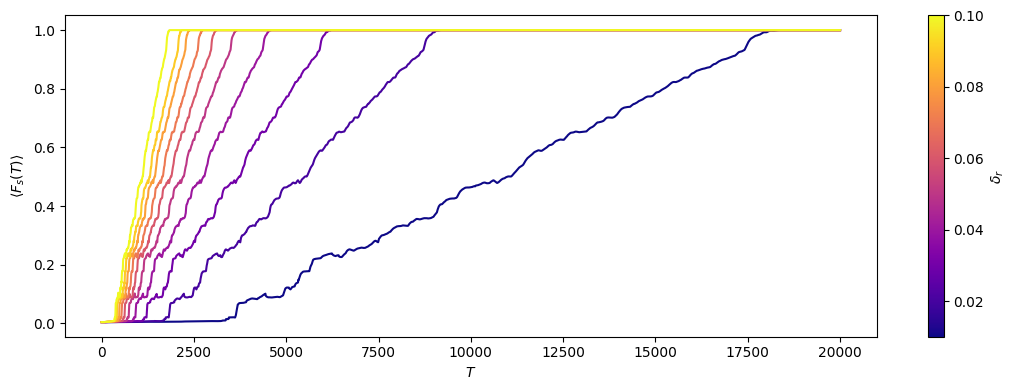

In [8]:
avg_repair = np.load('F_Deterministic1.npy', allow_pickle=True).item()

T_repair = 20000
deltas_r = np.linspace(0.01, 0.1, 10)

# --- GRÁFICA ---
t_repair = np.arange(T_repair + 1)

colormap = plt.colormaps.get_cmap('plasma')
norm = plt.Normalize(vmin=deltas_r.min(), vmax=deltas_r.max())

plt.figure(figsize=(11, 4))
for d in deltas_r:
    color = colormap(norm(d))
    plt.plot(t_repair, avg_repair[d],
             color=color, linewidth=1.5, label=f'$\\delta_r = {d:.2f}$')

sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('$\\delta_r$')

plt.xlabel("$T$")
plt.ylabel(r"$\left\langle F_s(T) \right\rangle$")
plt.tight_layout()
plt.show()